# Task 6 — Transformed Object Recognition

**Member 4** | Find an object even if rotated, scaled, or translated.

In [8]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import cv2
import numpy as np
import matplotlib.pyplot as plt
from cv_utils import load_image, show_image, show_images_row
from tasks.task6_object_recognition import detect_features, match_features, find_object

print("Imports OK")

Imports OK


## 1. Load Template & Scene

Prepare:
- `template.jpg` — the object to find
- `scene1.jpg` — a scene with the object rotated/scaled

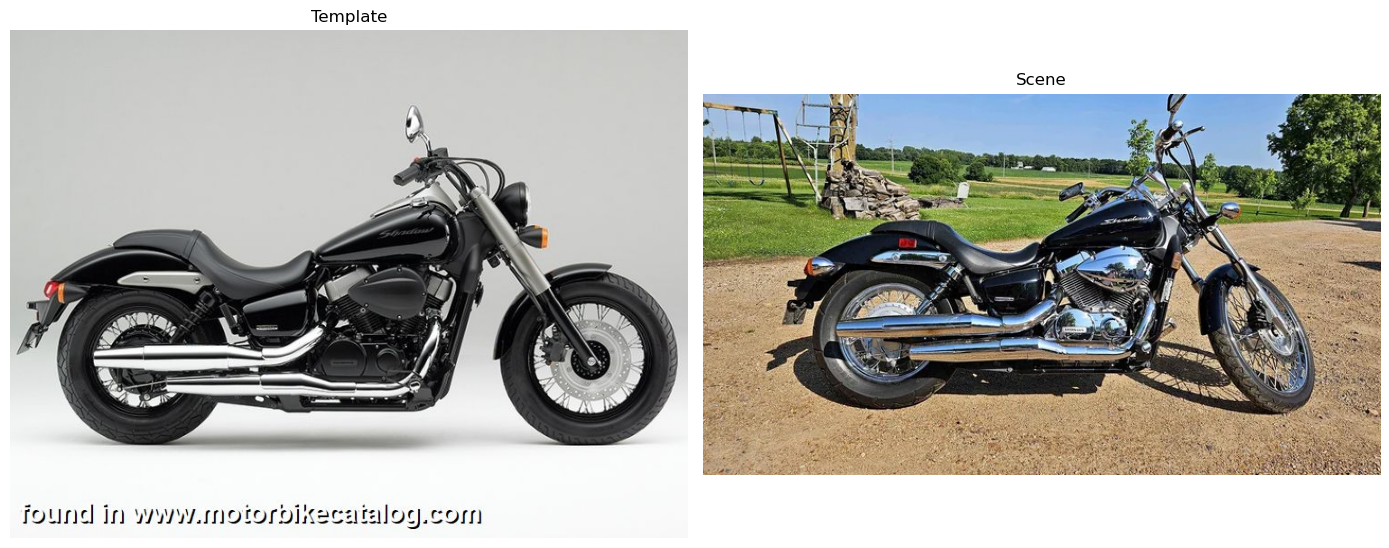

In [9]:
template = load_image('../images/task6/2009-shadow-phantom-jap.jpg')  # <-- CHANGE THIS
scene = load_image('../images/task6/first-time-buyer-rider-2k-for-a-2012-honda-shadow-good-deal-v0-3mt4qt9aoydd1.webp')        # <-- CHANGE THIS

show_images_row([template, scene], ["Template", "Scene"], figsize=(14, 6))

## 2. Detect & Match Features

Template keypoints: 1295
Scene keypoints: 1794


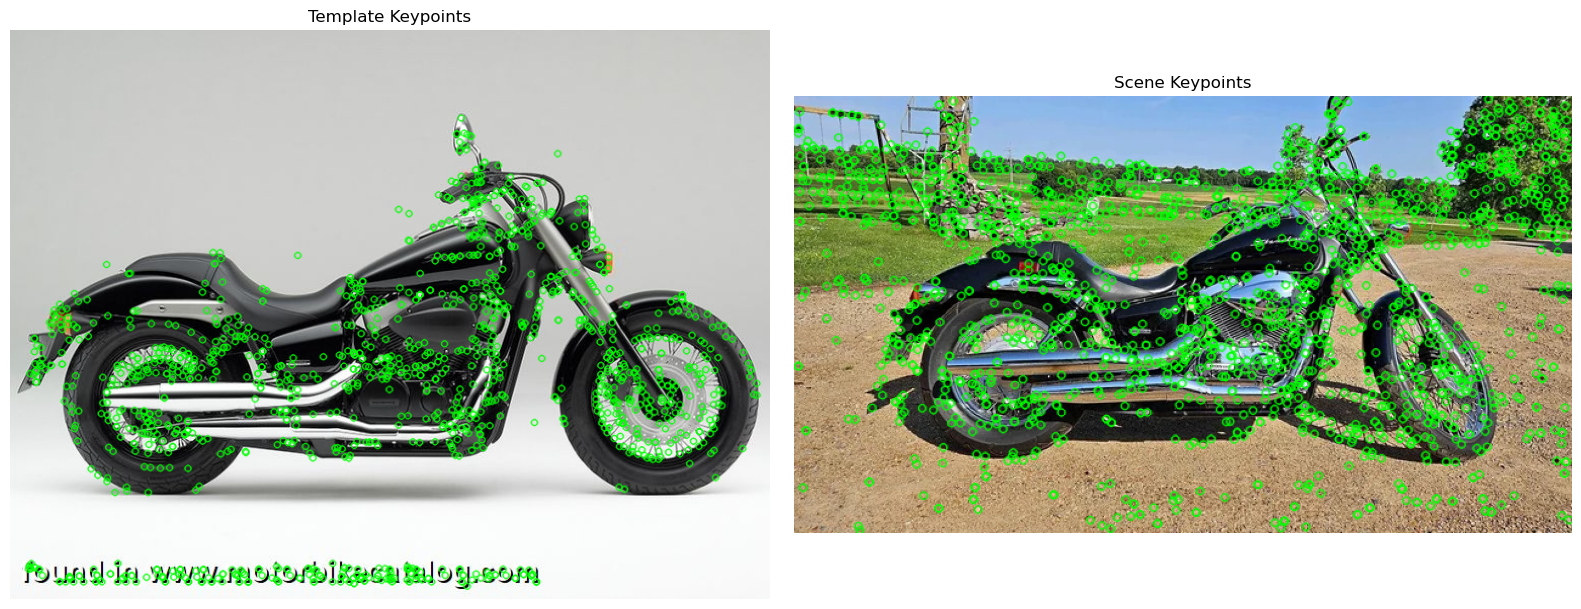

In [10]:
kp1, des1 = detect_features(template, method="sift")
kp2, des2 = detect_features(scene, method="sift")

print(f"Template keypoints: {len(kp1)}")
print(f"Scene keypoints: {len(kp2)}")

# Draw keypoints
img_kp1 = cv2.drawKeypoints(template, kp1, None, color=(0, 255, 0))
img_kp2 = cv2.drawKeypoints(scene, kp2, None, color=(0, 255, 0))
show_images_row([img_kp1, img_kp2], ["Template Keypoints", "Scene Keypoints"], figsize=(16, 6))

## 3. Object Detection

  Template keypoints: 1295
  Scene keypoints: 1794
  Good matches: 21
  Inliers: 8/21
  ✅ Object detected!


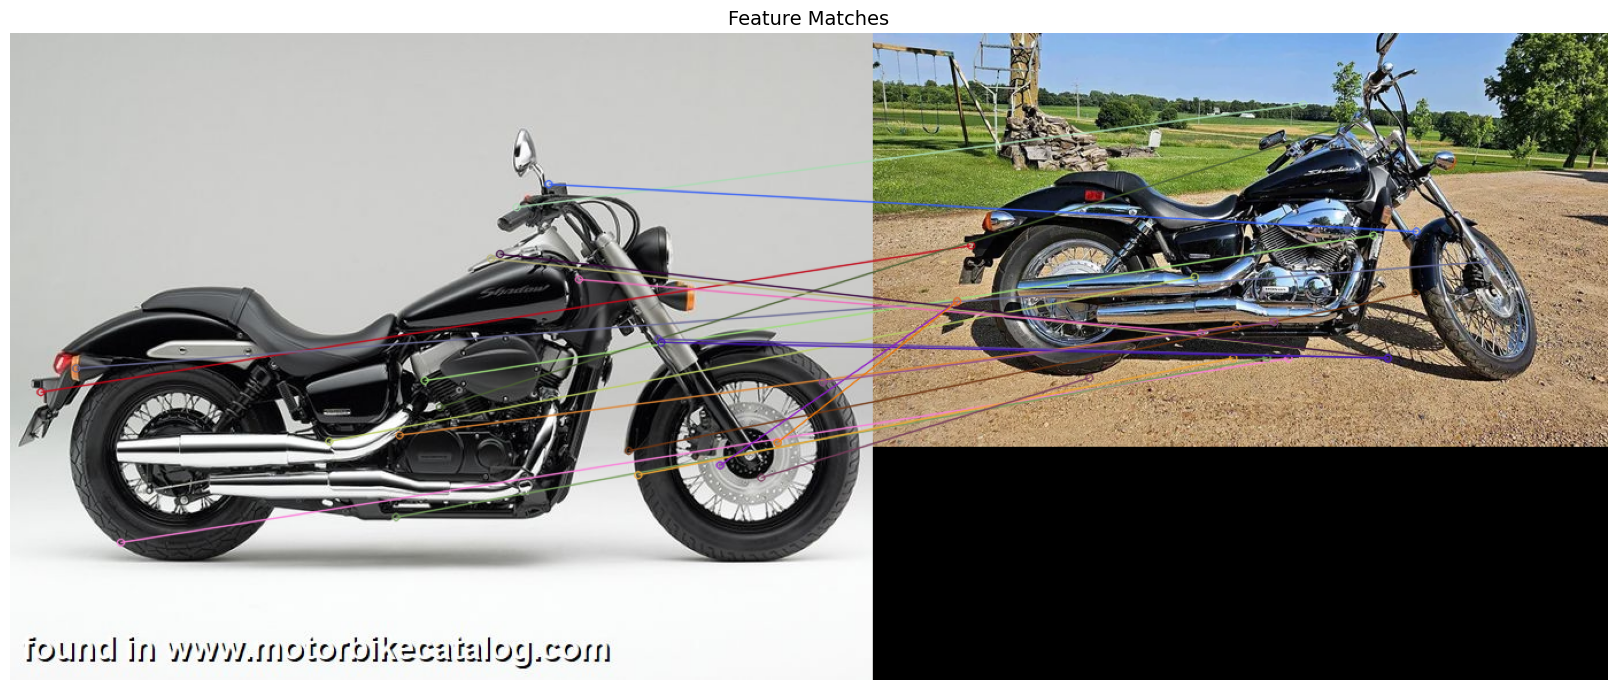

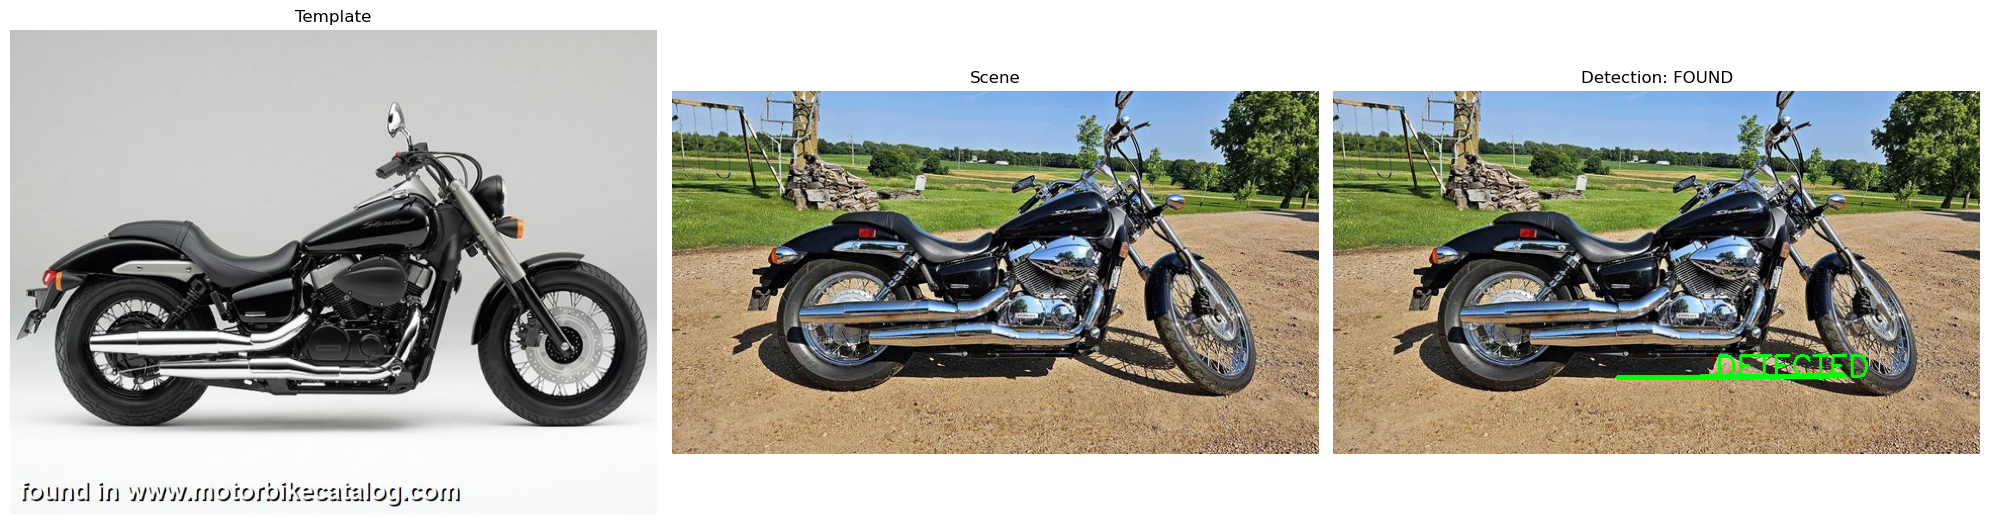

In [11]:
result, match_img, found = find_object(template, scene, method="sift")

if match_img is not None:
    show_image(match_img, "Feature Matches", figsize=(18, 7))

show_images_row([template, scene, result],
               ["Template", "Scene", f"Detection: {'FOUND' if found else ' NOT FOUND'}"],
               figsize=(20, 6))

## 4. Test with Transformed Versions

  Template keypoints: 978
  Scene keypoints: 1794
  Good matches: 22
  Inliers: 6/22
  ✅ Object detected!


c:\Users\ahmed\Desktop\study\semster 6\computer vision\final project\cv_utils\helpers.py:125: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\ahmed\anaconda3\envs\cv_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


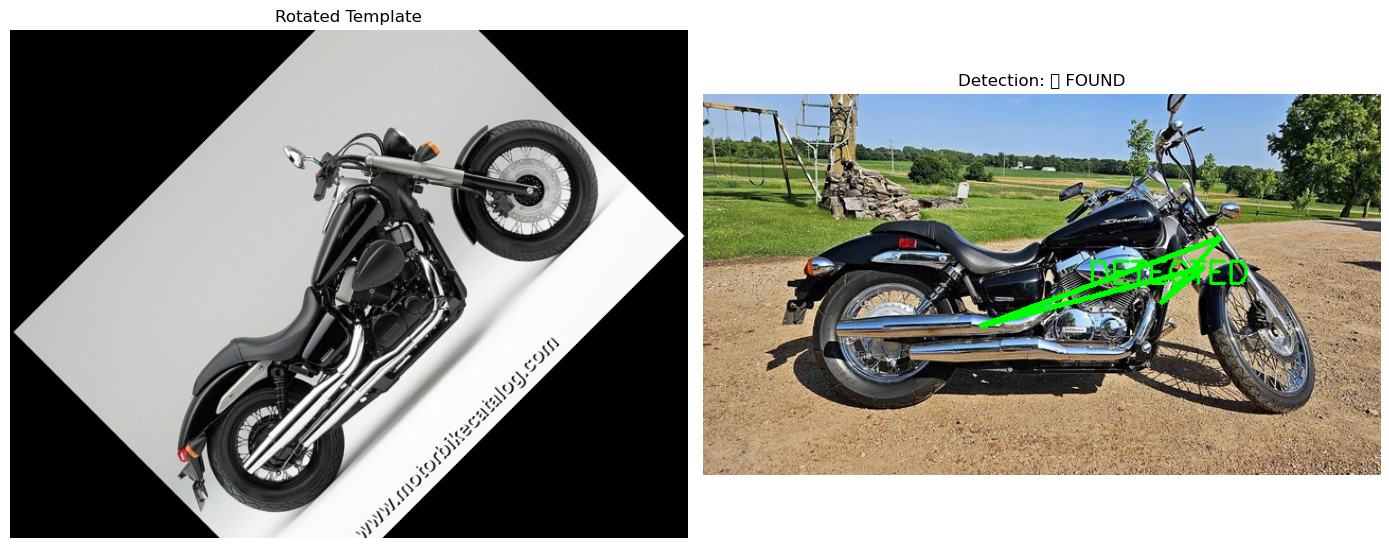

In [12]:
# Rotate the template and try again
h, w = template.shape[:2]
M = cv2.getRotationMatrix2D((w//2, h//2), 45, 0.8)  # 45° rotation, 80% scale
rotated = cv2.warpAffine(template, M, (w, h))

result2, _, found2 = find_object(rotated, scene, method="sift")
show_images_row([rotated, result2],
               ["Rotated Template", f"Detection: {'✅ FOUND' if found2 else '❌ NOT FOUND'}"],
               figsize=(14, 6))

## 5. Save Results

In [13]:
os.makedirs('../outputs/task6', exist_ok=True)
cv2.imwrite('../outputs/task6/detection_result.png', result)
if match_img is not None:
    cv2.imwrite('../outputs/task6/matches.png', match_img)
print("✅ Saved to outputs/task6/")

✅ Saved to outputs/task6/
